In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
df_results = pd.read_csv('results.csv')
df_drivers = pd.read_csv('drivers.csv')
display(df_results.head())
display(df_drivers.head())

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [4]:
print("Shape:", df_results.shape)
print("Shape:", df_drivers.shape)

Shape: (26759, 18)
Shape: (861, 9)


In [5]:
print(df_results.dtypes)
print(df_drivers.dtypes)

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number                 str
grid                 int64
position               str
positionText           str
positionOrder        int64
points             float64
laps                 int64
time                   str
milliseconds           str
fastestLap             str
rank                   str
fastestLapTime         str
fastestLapSpeed        str
statusId             int64
dtype: object
driverId       int64
driverRef        str
number           str
code             str
forename         str
surname          str
dob              str
nationality      str
url              str
dtype: object


In [6]:
display(df_results.describe())
display(df_drivers.describe())

,resultId,raceId,driverId,constructorId,grid,positionOrder,points,laps,statusId
count,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000
mean,13380.977391,551.687283,278.673530,50.180537,11.134796,12.794051,1.987632,46.301768,17.224971
std,7726.134642,313.265036,282.703039,61.551498,7.202860,7.665951,4.351209,29.496557,26.026104
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,6690.500000,300.000000,57.000000,6.000000,5.000000,6.000000,0.000000,23.000000,1.000000
50%,13380.000000,531.000000,172.000000,25.000000,11.000000,12.000000,0.000000,53.000000,10.000000
75%,20069.500000,811.000000,399.500000,63.000000,17.000000,18.000000,2.000000,66.000000,14.000000
max,26764.000000,1144.000000,862.000000,215.000000,34.000000,39.000000,50.000000,200.000000,141.000000


,driverId
count,861.000000
mean,431.061556
std,248.793797
min,1.000000
25%,216.000000
50%,431.000000
75%,646.000000
max,862.000000


In [7]:
print(df_results.isnull().sum())
print(df_drivers.isnull().sum())

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64
driverId       0
driverRef      0
number         0
code           0
forename       0
surname        0
dob            0
nationality    0
url            0
dtype: int64


In [8]:
print("Duplicates:", df_results.duplicated().sum())
print("Duplicates:", df_drivers.duplicated().sum())
print(df_results['positionOrder'].value_counts().head(10))

Duplicates: 0
Duplicates: 0
positionOrder
3     1135
4     1135
2     1134
11    1133
5     1132
6     1132
7     1132
8     1132
9     1131
10    1130
Name: count, dtype: int64


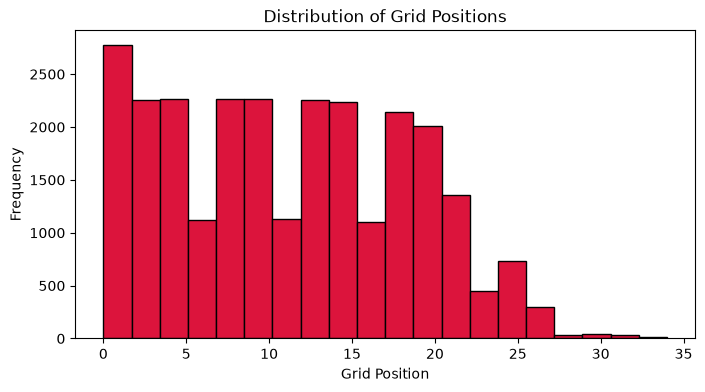

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(df_results['grid'], bins=20, color='crimson', edgecolor='black')
plt.title('Distribution of Grid Positions')
plt.xlabel('Grid Position')
plt.ylabel('Frequency')
plt.show()

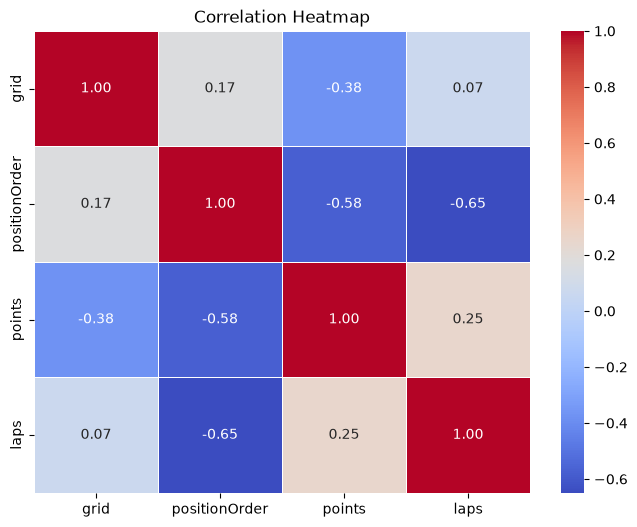

In [10]:
plt.figure(figsize=(8, 6))
cols = ['grid', 'positionOrder', 'points', 'laps']
sns.heatmap(df_results[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [46]:
df_clean = df_results.replace(r'^\s*\\N\s*$', np.nan, regex=True).copy()
df_clean['milliseconds'] = pd.to_numeric(df_clean['milliseconds'], errors='coerce')
med_val = df_clean['milliseconds'].median()
df_clean['milliseconds'] = df_clean['milliseconds'].fillna(med_val)
print("Mean:", df_clean['milliseconds'].mean())
print("Median:", med_val)

Mean: 5902318.5045965845
Median: 5788193.5


In [47]:
encoder = LabelEncoder()
df_drivers['nationality_encoded'] = encoder.fit_transform(df_drivers['nationality'])
display(df_drivers[['nationality','nationality_encoded']].head())
df_drivers_onehot = pd.get_dummies(df_drivers, columns=['code'], drop_first=True)
code_cols = [c for c in df_drivers_onehot.columns if c.startswith('code_')]
display(df_drivers_onehot[code_cols].head())

,nationality,nationality_encoded
0,British,9
1,German,20
2,German,20
3,Spanish,37
4,Finnish,18


,code_ALB,code_ALG,code_ALO,code_BAD,code_BAR,code_BEA,code_BIA,code_BOT,code_BOU,code_BUE,...,code_VET,code_VIL,code_WEB,code_WEH,code_WIN,code_WUR,code_YAM,code_ZHO,code_ZON,code_\N
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
